In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv('blinkit_data.csv')

In [7]:
df.head(5)

,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Item Weight,Sales,Rating
0,Regular,FDX32,Fruits and Vegetables,2012,OUT049,Tier 1,Medium,Supermarket Type1,0.100014,15.10,145.4786,5.0
1,Low Fat,NCB42,Health and Hygiene,2022,OUT018,Tier 3,Medium,Supermarket Type2,0.008596,11.80,115.3492,5.0
2,Regular,FDR28,Frozen Foods,2010,OUT046,Tier 1,Small,Supermarket Type1,0.025896,13.85,165.0210,5.0
3,Regular,FDL50,Canned,2000,OUT013,Tier 3,High,Supermarket Type1,0.042278,12.15,126.5046,5.0
4,Low Fat,DRI25,Soft Drinks,2015,OUT045,Tier 2,Small,Supermarket Type1,0.033970,19.60,55.1614,5.0


In [8]:
df.shape

(8523, 12)

In [9]:
df.size

102276

## Data types

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item Fat Content           8523 non-null   object 
 1   Item Identifier            8523 non-null   object 
 2   Item Type                  8523 non-null   object 
 3   Outlet Establishment Year  8523 non-null   int64  
 4   Outlet Identifier          8523 non-null   object 
 5   Outlet Location Type       8523 non-null   object 
 6   Outlet Size                8523 non-null   object 
 7   Outlet Type                8523 non-null   object 
 8   Item Visibility            8523 non-null   float64
 9   Item Weight                7060 non-null   float64
 10  Sales                      8523 non-null   float64
 11  Rating                     8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [11]:
df.describe()

,Outlet Establishment Year,Item Visibility,Item Weight,Sales,Rating
count,8523.000000,8523.000000,7060.000000,8523.000000,8523.000000
mean,2010.831867,0.066132,12.857645,140.992782,3.965857
std,8.371760,0.051598,4.643456,62.275067,0.605651
min,1998.000000,0.000000,4.555000,31.290000,1.000000
25%,2000.000000,0.026989,8.773750,93.826500,4.000000
50%,2012.000000,0.053931,12.600000,143.012800,4.000000
75%,2017.000000,0.094585,16.850000,185.643700,4.200000
max,2022.000000,0.328391,21.350000,266.888400,5.000000


In [12]:
df.isnull().sum()

Item Fat Content                0
Item Identifier                 0
Item Type                       0
Outlet Establishment Year       0
Outlet Identifier               0
Outlet Location Type            0
Outlet Size                     0
Outlet Type                     0
Item Visibility                 0
Item Weight                  1463
Sales                           0
Rating                          0
dtype: int64

In [14]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
8518    False
8519    False
8520    False
8521    False
8522    False
Length: 8523, dtype: bool

## Identify numerical and categorical columns

In [32]:
num_cols = df.select_dtypes(include="number").columns
num_cols

Index(['Outlet Establishment Year', 'Item Visibility', 'Item Weight', 'Sales',
       'Rating'],
      dtype='object')

In [33]:
num_cols = df.select_dtypes(include="number").columns
num_cols_df = pd.DataFrame(num_cols, columns=['column_name']) 
print("Total columns is:", len(num_cols))
print(num_cols_df)

Total columns is: 5
                 column_name
0  Outlet Establishment Year
1            Item Visibility
2                Item Weight
3                      Sales
4                     Rating


In [35]:
cat_cols = df.select_dtypes(include="object").columns
cat_cols

Index(['Item Fat Content', 'Item Identifier', 'Item Type', 'Outlet Identifier',
       'Outlet Location Type', 'Outlet Size', 'Outlet Type'],
      dtype='object')

In [36]:
cat_cols = df.select_dtypes(include="object").columns
cat_cols_df = pd.DataFrame(cat_cols, columns=['column_name']) 
print("Total columns is:", len(cat_cols))
print(cat_cols_df)

Total columns is: 7
            column_name
0      Item Fat Content
1       Item Identifier
2             Item Type
3     Outlet Identifier
4  Outlet Location Type
5           Outlet Size
6           Outlet Type


In [39]:
for col in cat_cols:
    print(f"{col}: {df[col].unique()}")

Item Fat Content: ['Regular' 'Low Fat' 'low fat' 'LF' 'reg']
Item Identifier: ['FDX32' 'NCB42' 'FDR28' ... 'FDU60' 'NCX53' 'FDE52']
Item Type: ['Fruits and Vegetables' 'Health and Hygiene' 'Frozen Foods' 'Canned'
 'Soft Drinks' 'Household' 'Snack Foods' 'Meat' 'Breads' 'Hard Drinks'
 'Others' 'Dairy' 'Breakfast' 'Baking Goods' 'Seafood' 'Starchy Foods']
Outlet Identifier: ['OUT049' 'OUT018' 'OUT046' 'OUT013' 'OUT045' 'OUT017' 'OUT010' 'OUT027'
 'OUT035' 'OUT019']
Outlet Location Type: ['Tier 1' 'Tier 3' 'Tier 2']
Outlet Size: ['Medium' 'Small' 'High']
Outlet Type: ['Supermarket Type1' 'Supermarket Type2' 'Grocery Store'
 'Supermarket Type3']


In [41]:
# COUNT DATA ON CATEGORICAL COLUMNS
for col in cat_cols:
    print(df[col].value_counts(normalize=True) * 100)
    print('---------------------------') 

Item Fat Content
Low Fat    59.709023
Regular    33.896515
LF          3.707615
reg         1.372756
low fat     1.314091
Name: proportion, dtype: float64
---------------------------
Item Identifier
FDW13    0.117330
FDG33    0.117330
FDX20    0.105597
NCL31    0.105597
FDQ40    0.105597
           ...   
FDN52    0.011733
FDQ60    0.011733
FDT35    0.011733
FDK57    0.011733
FDE52    0.011733
Name: proportion, Length: 1559, dtype: float64
---------------------------
Item Type
Fruits and Vegetables    14.455004
Snack Foods              14.079549
Household                10.676992
Frozen Foods             10.043412
Dairy                     8.001877
Canned                    7.614690
Baking Goods              7.602957
Health and Hygiene        6.101138
Soft Drinks               5.221166
Meat                      4.986507
Breads                    2.944972
Hard Drinks               2.510853
Others                    1.982870
Starchy Foods             1.736478
Breakfast                 1.

In [79]:
df['Item Fat Content'].unique()

array(['Regular', 'Low Fat'], dtype=object)

In [52]:
df['Item Fat Content'] = df['Item Fat Content'].replace({'LF': 'Low Fat',
                                                  'low fat': 'Low Fat',
                                                    'reg'  : 'Regular'})  
df['Item Fat Content']

0       Regular
1       Low Fat
2       Regular
3       Regular
4       Low Fat
         ...   
8518    Low Fat
8519    Low Fat
8520    Low Fat
8521    Regular
8522    Regular
Name: Item Fat Content, Length: 8523, dtype: object

In [53]:
df['Item Fat Content'].unique()

array(['Regular', 'Low Fat'], dtype=object)

### Business Requirements

#### KPI'S REQUIREMENTS

In [75]:
# Total sales
total_sales = df['Sales'].sum()
print(f"Total Sales: ${total_sales:,.0f}")

Total Sales: $1,201,681


In [76]:
# Average_sales
avg_sales = df['Sales'].mean()
print(f"Average Sales: ${avg_sales:,.0f}")

Average Sales: $141


In [77]:
# No of items sold
no_of_items_sold = df['Sales'].count()
print(f"No of items sold: {no_of_items_sold:,.0f}")

No of items sold: 8,523


In [78]:
# Average rattings
avg_ratings = df['Rating'].mean()
print(f"Average ratings: {avg_ratings:,.1f}")

Average ratings: 4.0


# **Univarient analysis**

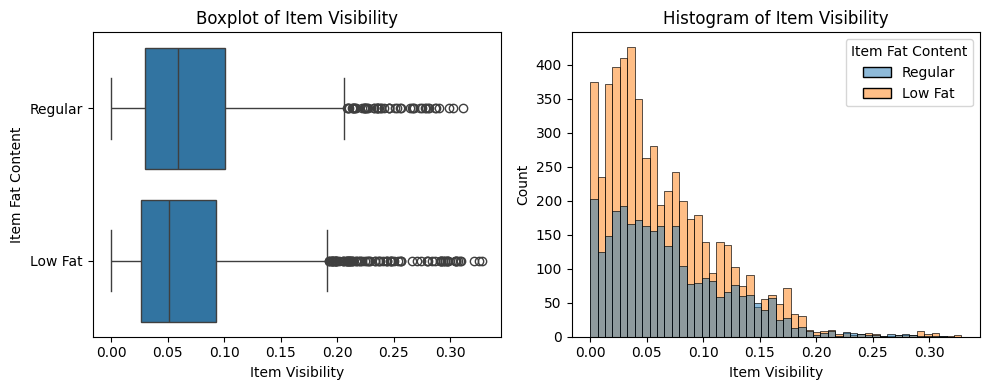

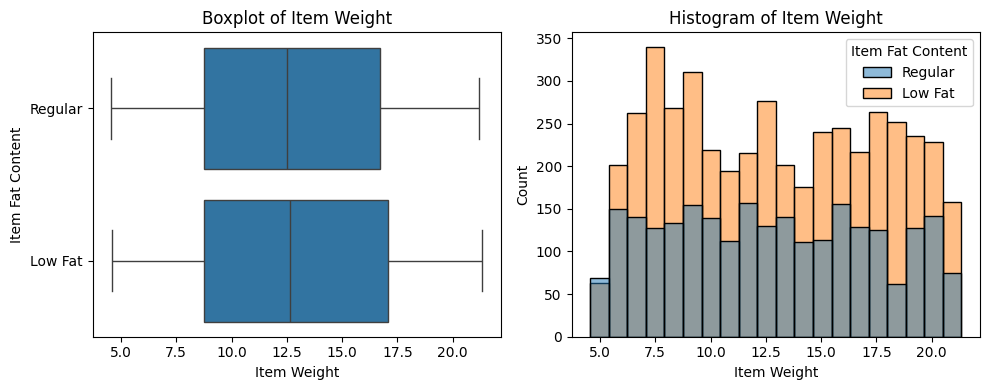

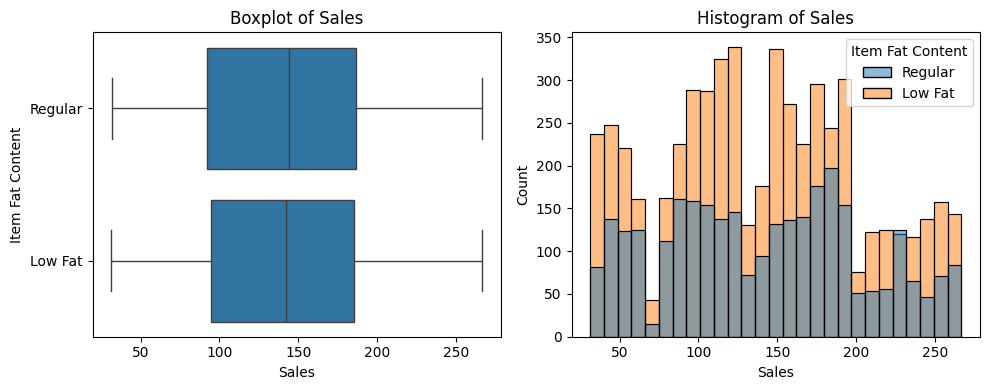

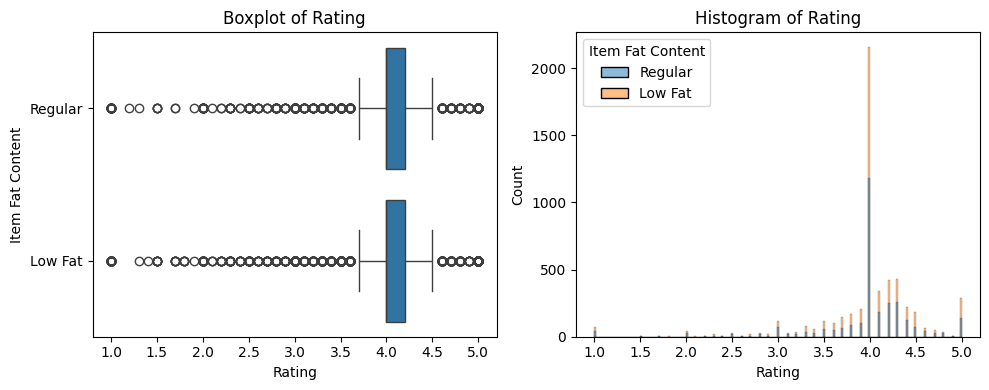

In [127]:
cols = ['Item Visibility', 'Item Weight', 'Sales', 'Rating']

for col in cols:
    plt.figure(figsize=(10,4))
    
    plt.subplot(1,2,1)
    sns.boxplot(data=df, y='Item Fat Content', x=col)
    plt.title(f'Boxplot of {col}')
    
    plt.subplot(1,2,2)
    sns.histplot(data=df, x=col, hue='Item Fat Content')
    plt.title(f'Histogram of {col}')
    plt.tight_layout()
    plt.show

## **Report**

- Item Weight and Sales show the largest variation across fat types.
- Item Visibility is more concentrated, suggesting placement may not heavily depend on fat content.
- Ratings indicate customer preference trends; low-fat items are slightly favored

### Total Sales by Fat Content

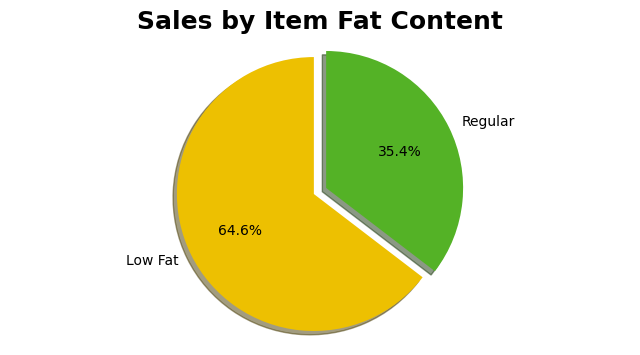

In [129]:
sales_by_fat = df.groupby('Item Fat Content')['Sales'].sum()
explode = (0, 0.1)
colors = ('#EDC001', '#54B226')  
plt.figure(figsize=(8,4))
plt.pie(sales_by_fat.values, labels=sales_by_fat.index, 
        autopct='%.1f%%',startangle=90,explode=explode,
        colors=colors,shadow=True)
plt.title('Sales by Item Fat Content',  fontweight='bold', fontsize=18)
plt.axis('equal')
plt.show()


### **Insights
- Low-fat products contribute ~65% of total sales, indicating a strong customer preference toward healthier options,
  making it a key area for business expansion

### **Total sales by item Types**

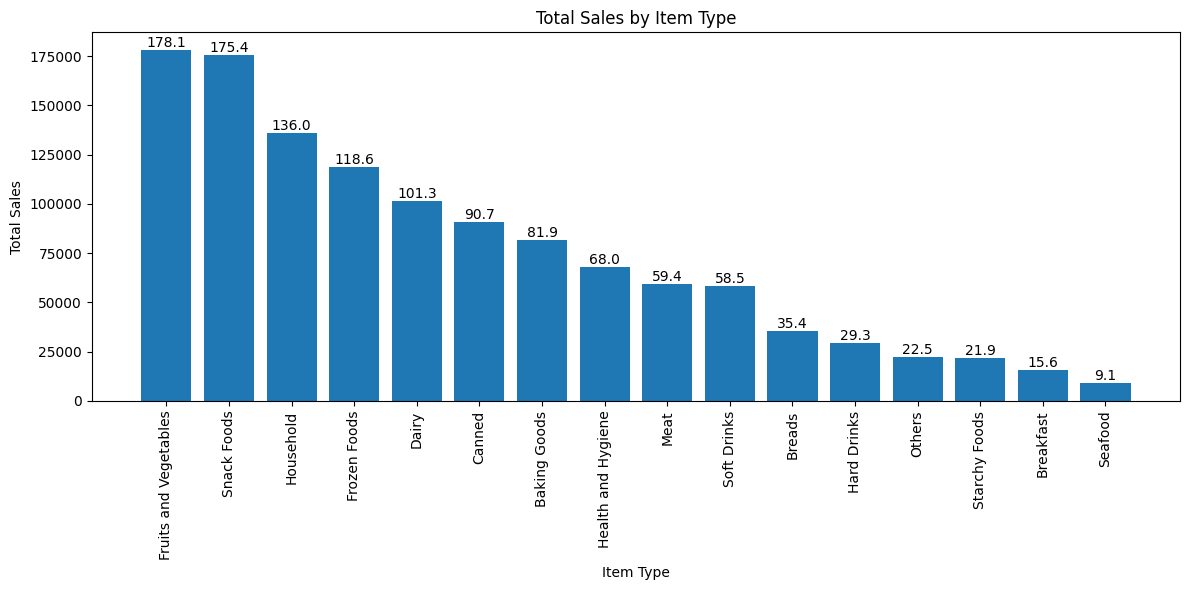

In [154]:
sales_by_item = df.groupby('Item Type')['Sales'].sum().sort_values(ascending=False)
plt.figure(figsize=(12,6))
bar = plt.bar(sales_by_item.index, sales_by_item.values)
plt.xticks(rotation=90)
plt.xlabel('Item Type')
plt.ylabel('Total Sales')
plt.title('Total Sales by Item Type')

for bar in bar:
    plt.text(bar.get_x() + bar.get_width()/2, 
             bar.get_height(), 
             f'{bar.get_height()/1000:.1f}', 
             ha='center', va='bottom')
plt.tight_layout()
plt.show()

### Insights

- Fresh products (Fruits & Vegetables) are the biggest driver  `high demand`
- Impulse buying categories (Snacks) also perform `strongly`
- Seafood & Breakfast items are underperforming  `need attention`
- Good balance between food and  household essentials

### **Fat Content by Outlet for Total Sales**

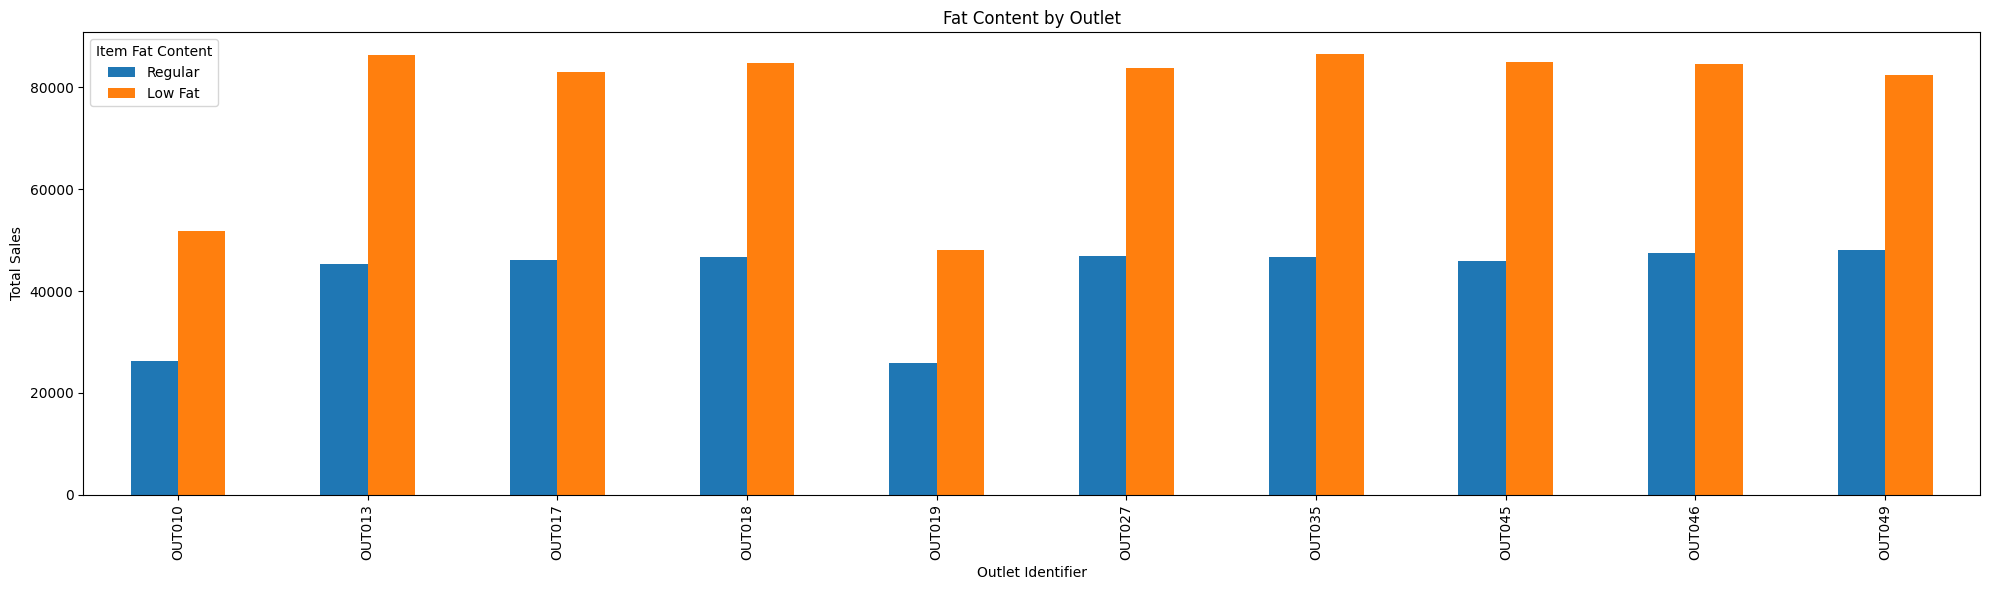

In [171]:
grouped = df.groupby(['Outlet Identifier', 'Item Fat Content'])['Sales'].sum().unstack()
grouped = grouped[['Regular', 'Low Fat']]

ax = grouped.plot(kind='bar', figsize=(20,6))
plt.xlabel('Outlet Identifier')
plt.ylabel('Total Sales')
plt.legend(title='Item Fat Content')
#plt.xticks(rotation=90)
plt.title('Fat Content by Outlet')
plt.tight_layout()
plt.show()

### Insights
- Health-conscious trend is consistent across all outlets
- High-performing outlets can be used as benchmark stores
- Underperforming outlets need strategy improvement (location, inventory, marketing)

### **Total Sales by Outlet Establishment**

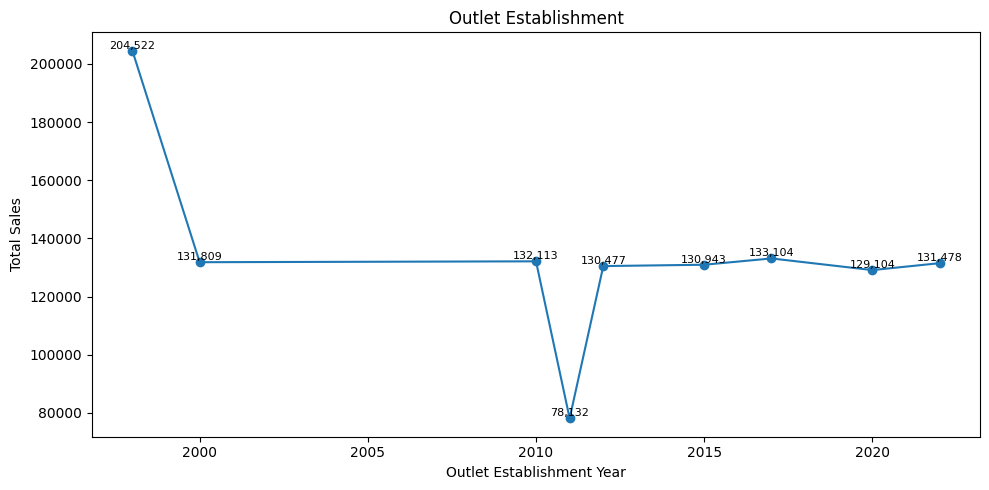

In [175]:
sales_by_year = df.groupby('Outlet Establishment Year')['Sales'].sum().sort_index()
plt.figure(figsize=(10,5))
plt.plot(sales_by_year.index, sales_by_year.values, marker='o')
plt.xlabel('Outlet Establishment Year')
plt.ylabel('Total Sales')
plt.title('Outlet Establishment')

for x,y in zip(sales_by_year.index, sales_by_year.values):
    plt.text(x,y,f'{y:,.0f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()


### Insights
- Older outlets (especially 1998) perform better → maturity matters
- New outlets are not outperforming older ones
- 2011 outlet is a clear underperformer (outlier)
- Overall trend = stable but no strong growth

### **Sales by Outlet Size**

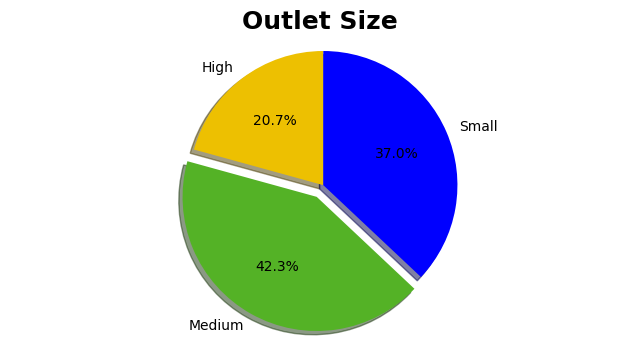

In [180]:
sales_by_size = df.groupby('Outlet Size')['Sales'].sum()
plt.figure(figsize=(8,4))
explode = (0, 0.1,0)
colors = ('#EDC001', '#54B226','Blue')  

plt.pie(sales_by_size.values, labels=sales_by_size.index, 
        autopct='%.1f%%',startangle=90,explode=explode,
        colors=colors,shadow=True)
plt.title('Outlet Size',  fontweight='bold', fontsize=18)
plt.axis('equal')
plt.show()

### Insights

- Majority of business comes from Medium-sized outlets which is 42.3%
- Indicates optimal balance of cost vs performance
- Small outlets also contribute significantly which is  37.0%
- Good for reach and accessibility
- Large outlets are fewer (only ~21%)
- High investment but limited presence

## **Sales by Outlet Location**

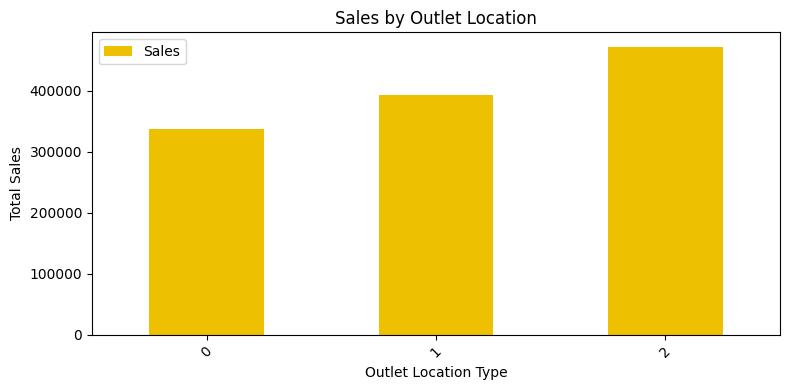

In [188]:
sales_by_location = df.groupby('Outlet Location Type')['Sales'].sum().reset_index()

sales_by_location.plot(kind='bar', figsize=(8,4), color='#EDC001',
                       rot=45, title='Sales by Outlet Location')
plt.xlabel('Outlet Location Type')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.show()

### Insights
- Sales increase steadily from Location Type 0 to Type 2. Type 2 performs best (~475K), while Type 0 is lowest (~350K) and 
  Type 1 is moderate (~400K). This indicates Type 2 locations drive higher revenue and can be used as a model to improve 
  other locations.

## Final Insights

- Low Fat products contribute 64.6% of total sales, showing strong customer preference for healthier options.
- Fruits & Vegetables and Snack Foods are the top revenue-generating categories.
- Seafood and Breakfast categories have the lowest sales contribution.
- Low Fat items outperform Regular items across all outlets consistently.
- Medium-sized outlets contribute the highest share (42.3%), making them the most efficient.
- Small outlets also have a significant presence (37%), supporting market reach.
- Large outlets contribute the least (20.7%), indicating limited expansion or high cost.
- Tier-1 / Location Type 2 outlets generate the highest overall sales.
- The 1998 outlet has the highest sales (~₹2.04L), showing strong customer loyalty.
- The 2011 outlet shows the lowest sales (~₹78K), indicating underperformance.
- Recent outlets show stable but not growing sales (~₹1.3L).

## Conclusion & Action
- To drive growth, the business should focus on low-fat products,
-  high-performing categories, and medium-sized outlets in prime
  locations while improving underperforming outlets and categories

## **************************--*****************************